### The resource for this lecture
https://nbviewer.org/urls/qutip.org/qutip-tutorials/tutorials-v5/lectures/Lecture-1-Jaynes-Cumming-model.ipynb

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from qutip import (about, basis, destroy, mesolve, ptrace, qeye,
                   tensor, wigner, anim_wigner)
# set a parameter to see animations in line
from matplotlib import rc
rc('animation', html='jshtml')

%matplotlib inline

### The Jaynes-Cummings Model

The Jaynes-Cummings model represents the fundamental paradigm for quantum mechanical light-matter interaction. It describes a single two-level atom coupled to a single quantized mode of an electromagnetic cavity. 

In the dipole interaction form, the total system Hamiltonian is expressed as:

$$ H = \hbar \omega_c a^\dagger a + \frac{1}{2} \hbar \omega_a \sigma_z + \hbar g \left( a^\dagger + a \right) \left( \sigma_- + \sigma_+ \right) $$

#### The Rotating-Wave Approximation (RWA)
By applying the rotating-wave approximation, rapidly oscillating counter-rotating terms ($a^\dagger \sigma_+$ and $a \sigma_-$) are neglected. This simplification is highly accurate in the near-resonant regime ($\omega_c \approx \omega_a$) where the coupling strength is weak ($g \ll \omega_c, \omega_a$). The effective Hamiltonian reduces to:

$$ H_{\text{RWA}} = \hbar \omega_c a^\dagger a + \frac{1}{2} \hbar \omega_a \sigma_z + \hbar g \left( a^\dagger \sigma_- + a \sigma_+ \right) $$

where:
* $\omega_c$ and $\omega_a$ denote the angular frequencies of the cavity mode and atomic transition, respectively.
* $g$ represents the light-matter coupling strength.
* $a^\dagger$ ($a$) are the bosonic creation (annihilation) operators for the cavity field.
* $\sigma_z$, $\sigma_+$, and $\sigma_-$ are the standard Pauli and ladder operators for the two-level atom.

We also use units where $\hbar = 1$:

In [2]:
wc = 2 * np.pi # Cavity frequency
wa = 2 * np.pi # atom frequency
g = 0.05 * 2 * np.pi # Coupling strength
kappa = 0.005 # Cavity Dissipation rate
gamma = 0.05 # atom dissipation rate
N = 15 # The number of cavity fock states is a quantum state that is an element of a Fock space 
       #with a well-defined number of particles (or quanta).
n_th_a = 0.0 # avg '#' of thermal bath excitation
use_rwa = True # rotating-wave approximation

tlist = np.linspace(0, 25, 101)

### Setup the operators, the Hamiltonian and initial state

In [3]:
# inital state
psi0 = tensor(basis(N, 0), basis(2, 1)) # start with an excited atom basis(2, 1)

#operators
a = tensor(destroy(N), qeye(2))
sm = tensor(qeye(N), destroy(2))

#Hamiltonaian
if use_rwa:
    H = wc * a.dag() * a + wa * sm.dag() * sm +\
    g * (a.dag() * sm + a * sm.dag())

else:
    H = wc * a.dag() * a + wa * sm.dag() * sm + \
        g * (a.dag() + a) * (sm + sm.dag())

### Create a list of collapse operators that describe the dissipation

In [4]:
c_ops = []

# cavity relaxation
rate = kappa * (1+ n_th_a)
if rate > 0.0:
    c_ops.append(np.sqrt(rate)* a)

# cavity excitation, if temperature > 0
rate = kappa * n_th_a
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a.dag())

# qubit relaxation
rate = gamma
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * sm)

### Evolve the system
Here we evolve the system with the Lindblad master equation solver, and we request that the expectation values of the operators  $a^\dagger a$ and  $\sigma_ + \sigma_ -$ are returned by the solver by passing the list [a()*a, sm.dag()*sm] as the fifth argument to the solver.

In [5]:
output = mesolve(H, psi0, tlist, c_ops, e_ops=[a.dag() * a, sm.dag() *sm])
output

<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.0001480579376220703
    preparation time: 0.00019812583923339844
    run time: 0.009261131286621094
    solver: 'Master Equation Evolution'
    num_collapse: 2
  Time interval: [0.0, 25.0] (101 steps)
  Number of e_ops: 2
  State not saved.
>

### Visualize the results
Here we plot the excitation probabilities of the cavity and the atom (these expectation values were calculated by the mesolve above). We can clearly see how energy is being coherently transferred back and forth between the cavity and the atom.

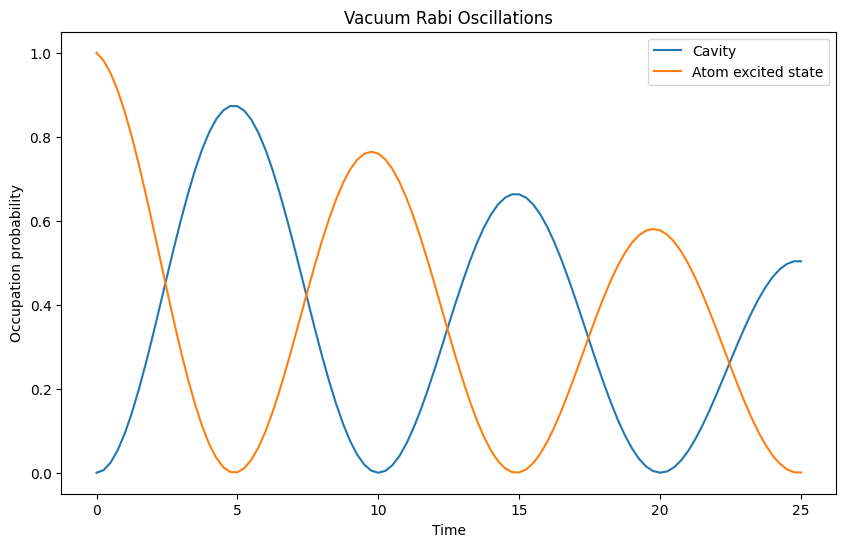

In [6]:
n_c = output.expect[0]
n_a = output.expect[1]

fig, axes = plt.subplots(1, 1, figsize = (10, 6))

axes.plot(tlist, n_c, label = "Cavity")
axes.plot(tlist, n_a, label = "Atom excited state")
axes.legend(loc=0)
axes.set_xlabel("Time")
axes.set_ylabel("Occupation probability")
axes.set_title("Vacuum Rabi Oscillations");

## Cavity wigner function
### https://en.wikipedia.org/wiki/Wigner_quasiprobability_distribution
### It is a generating function for all spatial autocorrelation functions of a given quantum-mechanical wavefunction $ψ(x)$. Thus, it maps on the quantum density matrix in the map between real phase-space functions and Hermitian operators introduced by Hermann Weyl in 1927, in a context related to representation theory in mathematics.

In [8]:
output = mesolve(H, psi0, tlist, c_ops)
"""recalculte the evolution without specifying any expectation value operators, which will result in 
that the solver returns a list of density matrices for the system for the given time coordinates."""
output

<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 3.6716461181640625e-05
    preparation time: 0.0001251697540283203
    run time: 0.008722066879272461
    solver: 'Master Equation Evolution'
    num_collapse: 2
  Time interval: [0.0, 25.0] (101 steps)
  Number of e_ops: 0
  States saved.
>

In [ ]:
print(type(output.states))
print(len(output.states))
print(output.states[-1])

<class 'list'>
101
Quantum object: dims=[[15, 2], [15, 2]], shape=(30, 30), type='oper', dtype=Dense, isherm=True
Qobj data =
[[4.96058553e-01+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j        ]
 [0.00000000e+00+0.j         4.81112490e-04+0.j
  0.00000000e+00-0.01549669j 0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
 

#### Let's look at the Wigner functions at the point in time when atom is in its ground state: $t=5,15,25$
#### For each of these points in time we need to:

1. ##### Find the system density matrix for the points in time that we are interested in.
2. ##### Trace out the atom and obtain the reduced density matrix for the cavity.
3. ##### Calculate and visualize the Wigner function for the reduced cavity density matrix.

In [ ]:
# find the indices of the density matrices for the times we are interested in
t_idx = np.where([tlist == t for t in [0.0, 5.0, 15.0, 25.0]])[1]
tlist[t_idx]

array([ 0.,  5., 15., 25.])

In [20]:
# get a list density matrices
rho_list = [output.states[i] for i in t_idx]
rho_list

[Quantum object: dims=[[15, 2], [15, 2]], shape=(30, 30), type='oper', dtype=Dense, isherm=True
 Qobj data =
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 

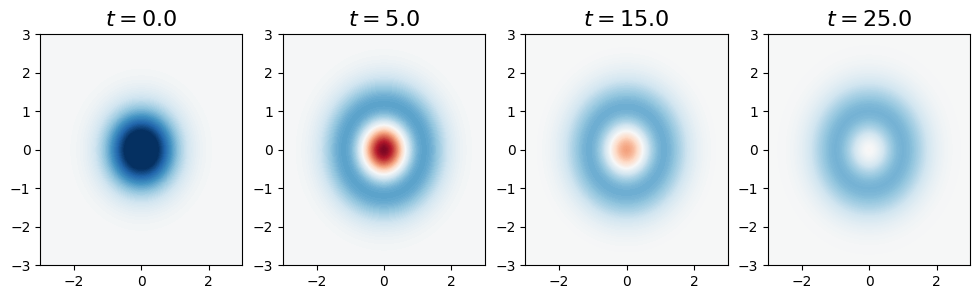

In [23]:
# loop over the list of density matrices
xvec = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, len(rho_list), sharex = True, 
                         figsize = (3 * len(rho_list), 3))

for idx, rho in enumerate(rho_list):
    """ trace out the atom from the density matrix, to obtain
        the reduced density matrix for the cavity"""
    rho_cavity = ptrace(rho, 0)

    # calculate its wigner function
    W = wigner(rho_cavity, xvec, xvec)

    #plot its wigner function
    axes[idx].contourf(
        xvec, 
        xvec,
        W,
        100, 
        norm = mpl.colors.Normalize(-0.25, 0.25),
        cmap = plt.get_cmap("RdBu")
    )

    axes[idx].set_title(r"$t = %.1f$" %  tlist[t_idx][idx], fontsize = 16)

#### At $t=0$, the cavity is in its ground state. At $t=5,15,25$ it reaches its maximum occupation in this Rabi-vacuum oscillation process. We can note that for $t=5$ and $t=15$ the Wigner function has negative values, indicating a truly quantum mechanical state. At $t=25$, however, the Wigner function no longer has negative values and can therefore be considered a classical state.

## qutip.anim_wigner is useful to visualize the oscillation
#### It calculates the wigner function inside it so all you need to do is pass the reduced density matrices. You can pass options to it. 

In [29]:
fig = plt.figure(figsize = (6, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.view_init(elev = 0)

rho_cavity = list()
xvec = np.linspace(-3, 3, 150)

for idx, rho in enumerate(output.states):
    rho_cavity.append(ptrace(rho, 0))

fig, ani = anim_wigner(rho_cavity, xvec, xvec, projection = '3d', colorbar = True, fig = fig, ax = ax)

plt.close(fig)
ani

### Alternative view of the same thing

Done!


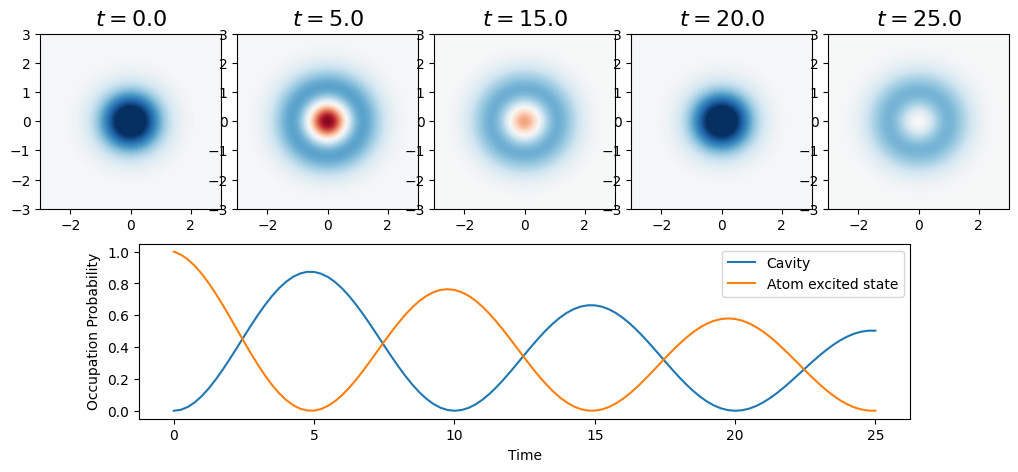

In [ ]:
t_idx = np.where([tlist == t for t in [0.0, 5.0, 15, 20, 25]]) [1]
rho_list = [output.states[i] for i in t_idx]

fig_grid = (2, len(rho_list) * 2)
fig = plt.figure(figsize = (2.5 * len(rho_list), 5))

for idx, rho in enumerate(rho_list):
    rho_cavity = ptrace(rho, 0)
    W = wigner(rho_cavity, xvec, xvec)
    ax = plt.subplot2grid(fig_grid, (0, 2 * idx), colspan = 2)
    ax.contourf(
        xvec, 
        xvec,
        W, 
        100,
        norm = mpl.colors.Normalize(-0.25, 0.25),
        cmap = plt.get_cmap("RdBu"),
    )
    ax.set_title(r"$t = %.1f$" % tlist[t_idx][idx], fontsize=16)

# Plot the cavity occuption probability in the ground state
ax = plt.subplot2grid(fig_grid, (1, 1), colspan = (fig_grid[1] - 2))
ax.plot(tlist, n_c, label = "Cavity")
ax.plot(tlist, n_a, label = "Atom excited state")
ax.legend()

ax.set_xlabel("Time")
ax.set_ylabel("Occupation Probability");